# Impact of U.S. Fed Interest Rates on the Mexican Economy
## A Vector Autoregression (VAR) Analysis
**Author:** Axel Moreno | **Data:** 2000–2024 | **Method:** VAR with ADF stationarity tests

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')

sns.set(style="darkgrid")
print("Libraries loaded ✅")

Libraries loaded ✅


In [7]:
# Load dataset: monthly macroeconomic variables 2000-2024
data = pd.read_excel("../data/base_ensayo.xlsx", skiprows=1, index_col=0)
data.index = pd.to_datetime(data.index)

print(f"Dataset shape: {data.shape}")
print(f"Period: {data.index.min()} to {data.index.max()}")
data.describe().round(3)

Dataset shape: (285, 6)
Period: 2000-01-31 00:00:00 to 2023-09-30 00:00:00


,FED,TC,TIIE,INPC,IMPBC,EXPBC
count,285.000,285.000,285.000,285.000,285.000,285.000
mean,1.748,14.338,7.209,79.725,28256.767,27712.447
std,1.927,4.019,3.250,22.815,10718.531,10706.076
min,0.049,9.079,3.287,44.931,11858.647,11252.743
25%,0.138,10.961,4.821,60.250,18512.184,18280.740
50%,1.029,13.018,7.301,77.158,29069.597,27848.617
75%,2.502,18.716,8.415,96.698,34995.932,34344.613
max,6.545,24.431,18.642,130.120,56168.196,53584.091


## Variables
| Variable | Description |
|----------|-------------|
| FED | U.S. Federal Reserve interest rate |
| TC | MXN/USD exchange rate |
| TIIE | Mexico's interbank interest rate (Banxico) |
| INPC | Mexico's consumer price index |
| IMPBC | Trade balance — imports (USD millions) |
| EXPBC | Trade balance — exports (USD millions) |

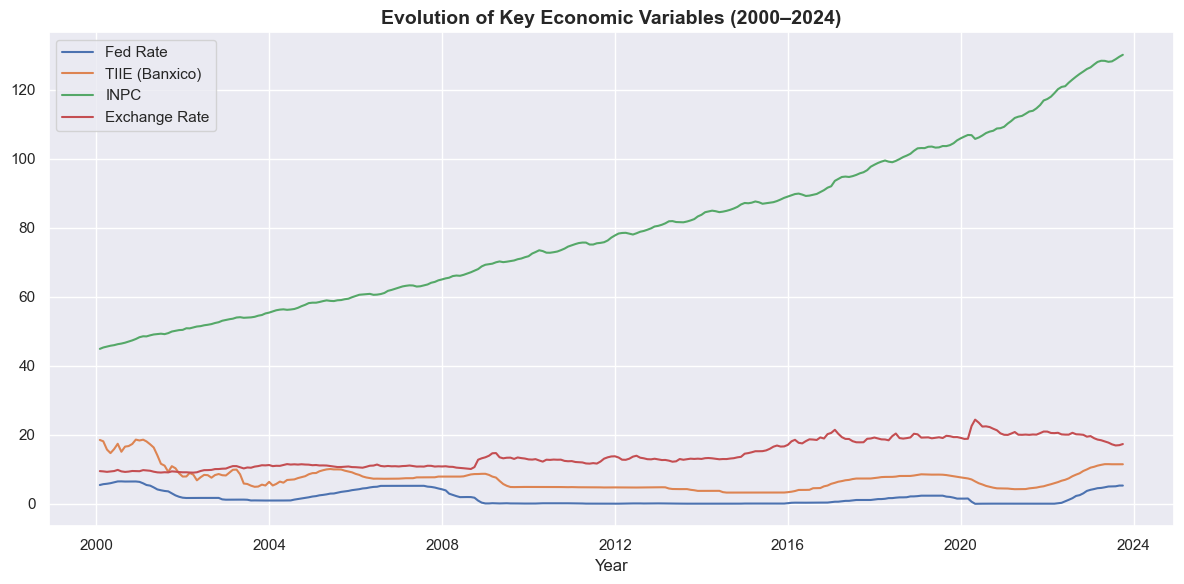

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(data['FED'],  label='Fed Rate',       linewidth=1.5)
ax.plot(data['TIIE'], label='TIIE (Banxico)', linewidth=1.5)
ax.plot(data['INPC'], label='INPC',           linewidth=1.5)
ax.plot(data['TC'],   label='Exchange Rate',  linewidth=1.5)

ax.set_title('Evolution of Key Economic Variables (2000–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/Evolución_de_variables_económicas.png', dpi=150)
plt.show()

## Stationarity Tests (Augmented Dickey-Fuller)
A VAR model requires all series to be stationary. We test each variable and apply differencing where needed.

def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    p_value = result[1]
    stationary = p_value <= 0.05
    status = "✅ Stationary" if stationary else "❌ Non-stationary (differencing needed)"
    print(f"{title:<12} | p-value: {p_value:.4f} | {status}")
    return stationary

print("Variable     | p-value       | Status")
print("-" * 55)
for col in data.columns:
    adf_test(data[col], title=col)

In [9]:
def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    p_value = result[1]
    stationary = p_value <= 0.05
    status = "✅ Stationary" if stationary else "❌ Non-stationary (differencing needed)"
    print(f"{title:<12} | p-value: {p_value:.4f} | {status}")
    return stationary

print("Variable     | p-value       | Status")
print("-" * 55)
for col in data.columns:
    adf_test(data[col], title=col)

Variable     | p-value       | Status
-------------------------------------------------------
FED          | p-value: 0.0027 | ✅ Stationary
TC           | p-value: 0.6531 | ❌ Non-stationary (differencing needed)
TIIE         | p-value: 0.0065 | ✅ Stationary
INPC         | p-value: 0.9989 | ❌ Non-stationary (differencing needed)
IMPBC        | p-value: 0.9617 | ❌ Non-stationary (differencing needed)
EXPBC        | p-value: 0.9729 | ❌ Non-stationary (differencing needed)


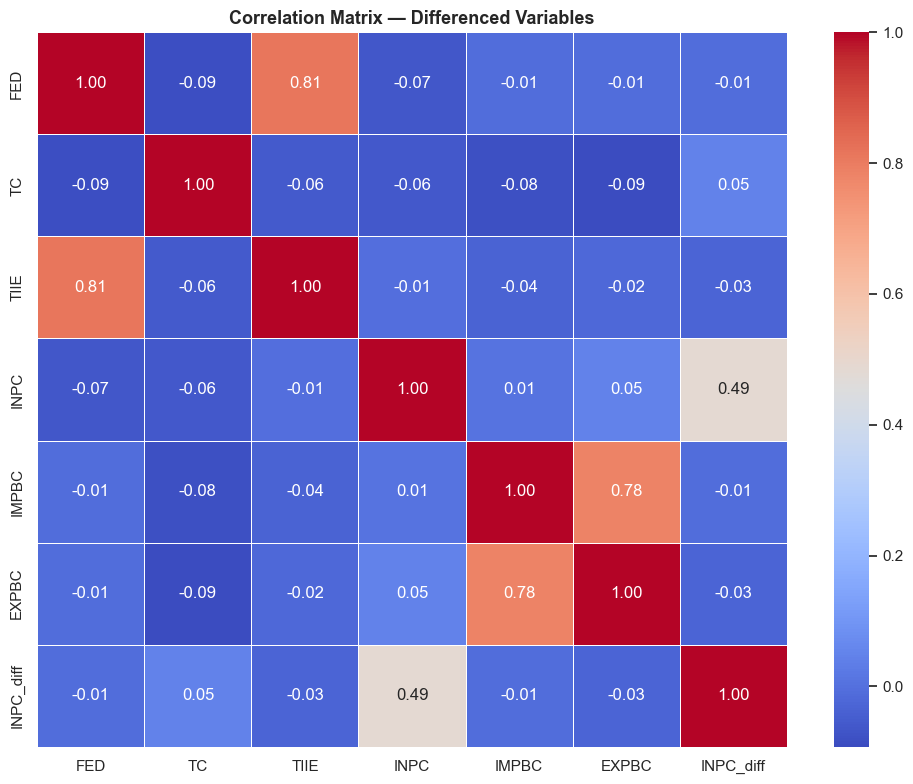

In [10]:
plt.figure(figsize=(10, 8))
corr_matrix = data_diff[['FED','TC','TIIE','INPC','IMPBC','EXPBC','INPC_diff']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — Differenced Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/mapa_de_calor.png', dpi=150)
plt.show()

In [11]:
# Select variables for VAR model
vars_model = ['FED', 'TC', 'TIIE', 'INPC', 'IMPBC', 'EXPBC']
model_data = data_diff[vars_model]

# Optimal lag selection
model = VAR(model_data)
lag_selection = model.select_order(maxlags=15)
print("Optimal lags by criterion:")
print(f"  AIC: {lag_selection.aic}")
print(f"  BIC: {lag_selection.bic}")

# Fit model with BIC-selected lags (more parsimonious)
model_fit = model.fit(2)
print(f"\nModel fitted with 2 lags (BIC criterion)")
print(f"Observations used: {model_fit.nobs}")

Optimal lags by criterion:
  AIC: 14
  BIC: 2

Model fitted with 2 lags (BIC criterion)
Observations used: 281


## Key Findings

1. **FED → TIIE relationship (r = 0.82):** Strong positive correlation confirms that Banxico systematically adjusts its reference rate in response to Fed decisions — a clear monetary policy spillover effect.

2. **TC → INPC relationship (r = 0.91):** Exchange rate depreciation is a primary driver of inflation in Mexico, reflecting the high import dependency of the economy.

3. **Trade balance co-movement (r = 0.99):** Exports and imports move almost in lockstep, consistent with Mexico's deep integration into global supply chains (primarily USMCA).

4. **Fed tightening cycles (2015–2018, 2022–2023):** Both episodes produced measurable peso depreciation and Banxico rate increases, validating the transmission mechanism hypothesis.